# NIFTY 50 Event Study

**Hypothesis:** After a *significant* one-day close-to-close fall in NIFTY 50, the index tends to recover over the next few trading days.

This notebook is the research engine for that hypothesis. It does not hunt for the prettiest parameter combination. Primary rules are fixed first, then robustness, out-of-sample, and a simple cost-aware backtest are used to try to break the result.

**Data used:** the NSE daily OHLC file in this folder (`NIFTY 50-23-09-2025-to-23-09-2026.csv`). Coverage is about one year, so sample size is a first-class limitation and is treated as such throughout.


## 1. Research question

| Item | Choice |
|---|---|
| Question | After NIFTY 50 falls by at least 2% close-to-close, are next-day-open to subsequent-close returns positive on average? |
| Null | Mean forward return after events is ≤ 0 |
| Alternative | Mean forward return after events is > 0 |
| Economic companion | Do event-window returns differ from ordinary NIFTY holding-period returns? |

**Failure conditions (pre-committed):** the hypothesis is treated as unsupported if (a) forward returns are not consistently positive across the primary holding periods, (b) event-period returns do not materially differ from the non-event baseline, or (c) the relationship disappears out of sample after parameters are frozen.


## 2. Configuration


In [2]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
np.random.seed(42)

DATA_PATH = next(Path(".").glob("NIFTY 50*.csv"))

# Primary research rules — chosen on rationale, then frozen for out-of-sample.
EVENT_THRESHOLD = -0.02          # significant fall: daily close-to-close return <= -2%
HOLDING_DAYS = 5                 # primary horizon
FORWARD_HORIZONS = (1, 3, 5)     # days from entry
COOLDOWN_DAYS = 3                # ignore new events for N trading days after an event
OOS_START = pd.Timestamp("2026-04-01")  # development: before this date

# Backtest frictions (round-trip applied at exit as a simple cost model).
TRANSACTION_COST = 0.0005        # 5 bps round-trip
SLIPPAGE = 0.0005                # 5 bps round-trip (cannot assume fill at the printed open/close)

BOOTSTRAP_REPS = 10_000
ALPHA = 0.05

print("Data file:", DATA_PATH.resolve())
print("Primary threshold:", EVENT_THRESHOLD)
print("Primary holding days:", HOLDING_DAYS)
print("Cooldown:", COOLDOWN_DAYS)
print("OOS start:", OOS_START.date())


Data file: C:\Users\saksham\Documents\suas_quant\NIFTY 50-23-09-2025-to-23-09-2026.csv
Primary threshold: -0.02
Primary holding days: 5
Cooldown: 3
OOS start: 2026-04-01


## 3. Load data

NSE files in this export are newest-first, with trailing spaces in column names. Dates are parsed after stripping. Empty trailing rows are dropped.


In [3]:
raw = pd.read_csv(DATA_PATH)
print("Raw columns:", list(raw.columns))
print("Raw shape:", raw.shape)
raw.head()


Raw columns: ['SN', 'Date ', 'Open ', 'High ', 'Low ', 'Close ', 'Shares Traded ', 'Turnover (₹ Cr)']
Raw shape: (249, 8)


,SN,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,1,23-Sep-26,"23,352.150000","23,466.900000","23,349.550000","23,446.800000","237,608,688.000000","17,215.760000"
1,2,22-Sep-26,"23,454.050000","23,489.000000","23,285.750000","23,329.000000","244,146,220.000000","19,610.730000"
2,3,21-Sep-26,"23,330.200000","23,466.800000","23,314.800000","23,414.300000","213,639,227.000000","17,770.460000"
3,4,18-Sep-26,"23,334.700000","23,389.150000","23,286.600000","23,346.400000","375,346,024.000000","31,510.280000"
4,5,17-Sep-26,"23,195.250000","23,363.550000","23,193.650000","23,270.600000","259,700,999.000000","18,775.300000"


In [4]:
df = raw.copy()
df.columns = df.columns.str.strip()

ohlc_cols = ["Open", "High", "Low", "Close"]
keep = ["Date"] + ohlc_cols
df = df[keep].copy()
df = df.dropna(how="all")

for c in ohlc_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["Date_raw"] = df["Date"].astype(str).str.strip()
df["Date"] = pd.to_datetime(df["Date_raw"], format="%d-%b-%y", errors="coerce")

print("Parsed rows:", len(df))
print("Unparseable dates:", int(df["Date"].isna().sum()))
df.head()


Parsed rows: 248
Unparseable dates: 1


,Date,Open,High,Low,Close,Date_raw
0,2026-09-23,"23,352.150000","23,466.900000","23,349.550000","23,446.800000",23-Sep-26
1,2026-09-22,"23,454.050000","23,489.000000","23,285.750000","23,329.000000",22-Sep-26
2,2026-09-21,"23,330.200000","23,466.800000","23,314.800000","23,414.300000",21-Sep-26
3,2026-09-18,"23,334.700000","23,389.150000","23,286.600000","23,346.400000",18-Sep-26
4,2026-09-17,"23,195.250000","23,363.550000","23,193.650000","23,270.600000",17-Sep-26


## 4. Data validation

Weekends are not treated as missing data. Gaps of 3 calendar days over a weekend, or longer around exchange holidays, are expected. Extreme *internally consistent* returns are retained because they are economically meaningful and may be the events themselves.

Two records in this file are not internally consistent / not parseable. They are investigated, not silently deleted.


In [5]:
print("=== Missing Date after parse ===")
print(int(df["Date"].isna().sum()))
print(df.loc[df["Date"].isna(), ["Date_raw", *ohlc_cols]])

print("\n=== Duplicate Date (among parsed) ===")
parsed = df.dropna(subset=["Date"])
print(int(parsed["Date"].duplicated().sum()))

print("\n=== Missing OHLC ===")
print(df[ohlc_cols].isna().sum())


=== Missing Date after parse ===
1
   Date_raw          Open          High           Low         Close
36    B38-1 24,572.700000 24,774.300000 24,515.150000 24,774.300000

=== Duplicate Date (among parsed) ===
0

=== Missing OHLC ===
Open     0
High     0
Low      0
Close    0
dtype: int64


In [6]:
# Logical OHLC relationships
ohlc_ok = (
    (df["High"] >= df["Open"])
    & (df["High"] >= df["Close"])
    & (df["Low"] <= df["Open"])
    & (df["Low"] <= df["Close"])
    & (df["High"] >= df["Low"])
    & df[ohlc_cols].notna().all(axis=1)
)
print("Invalid OHLC rows:", int((~ohlc_ok).sum()))
df.loc[~ohlc_ok, ["Date_raw", "Date", *ohlc_cols]]


Invalid OHLC rows: 1


,Date_raw,Date,Open,High,Low,Close
7,11-Sep-26,2026-09-11,"23,270.300000","23,448.100000","23,231.400000",6.000000


### Repair log

| Issue | Evidence | Action |
|---|---|---|
| `Close = 6` on 11-Sep-2026 | High/Low around 23,200–23,400; Close cannot be 6. Fails High ≥ Close and Low ≤ Close. | Drop. This is corruption, not a crash. |
| Date `B38-1` | Excel-style artefact. Neighbours are 04-Aug-2026 and 31-Jul-2026. 03-Aug-2026 is the missing Monday. OHLC is internally consistent. | Assign 03-Aug-2026. |
| Blank trailing row | All fields empty | Drop. |


In [7]:
repair_notes = []

# Infer the unparseable date from the surrounding (file-order) neighbours.
bad_date_idx = df.index[df["Date"].isna() & df[ohlc_cols].notna().all(axis=1)]
for i in bad_date_idx:
    prev_parsed = df.loc[: i - 1, "Date"].dropna()
    next_parsed = df.loc[i + 1 :, "Date"].dropna()
    # File is newest-first: previous row is a later calendar date, next row is an earlier one.
    later = prev_parsed.iloc[-1] if len(prev_parsed) else pd.NaT
    earlier = next_parsed.iloc[0] if len(next_parsed) else pd.NaT
    inferred = pd.Timestamp("2026-08-03")
    df.loc[i, "Date"] = inferred
    repair_notes.append(
        f"Row {i}: Date_raw={df.loc[i, 'Date_raw']!r} inferred as {inferred.date()} "
        f"(neighbours later={None if pd.isna(later) else later.date()}, "
        f"earlier={None if pd.isna(earlier) else earlier.date()})"
    )

invalid_mask = ~ohlc_ok
n_drop_ohlc = int(invalid_mask.sum())
if n_drop_ohlc:
    repair_notes.append(f"Dropped {n_drop_ohlc} row(s) failing OHLC inequalities (corrupted Close).")
    df = df.loc[~invalid_mask].copy()

df = df.dropna(subset=["Date", *ohlc_cols]).copy()
df = df.sort_values("Date").drop_duplicates(subset=["Date"], keep="first")
df = df.reset_index(drop=True)

print("Repair notes:")
for note in repair_notes:
    print("-", note)

print("\nMonotonic dates:", bool(df["Date"].is_monotonic_increasing))
print("Duplicate dates:", int(df["Date"].duplicated().sum()))
print("Start:", df["Date"].min().date())
print("End:", df["Date"].max().date())
print("Trading observations:", len(df))


Repair notes:
- Row 36: Date_raw='B38-1' inferred as 2026-08-03 (neighbours later=2026-08-04, earlier=2026-07-31)
- Dropped 1 row(s) failing OHLC inequalities (corrupted Close).

Monotonic dates: True
Duplicate dates: 0
Start: 2025-09-23
End: 2026-09-23
Trading observations: 247


In [8]:
# Calendar gaps: weekdays with no row. Weekends are expected; weekday gaps are holidays or missing data.
full_bdays = pd.bdate_range(df["Date"].min(), df["Date"].max(), freq="C")
missing_weekdays = full_bdays.difference(df["Date"])
print("Weekday dates with no observation:", len(missing_weekdays))
print(missing_weekdays[:30].strftime("%Y-%m-%d").tolist())
if len(missing_weekdays) > 30:
    print("...")

gaps = df["Date"].diff().dt.days
print("\nLargest calendar gaps (days between consecutive rows):")
display(df.assign(gap_days=gaps).nlargest(8, "gap_days")[["Date", "gap_days", "Close"]])


Weekday dates with no observation: 16
['2025-10-02', '2025-10-22', '2025-11-05', '2025-12-25', '2026-01-15', '2026-01-26', '2026-03-03', '2026-03-26', '2026-03-31', '2026-04-03', '2026-04-14', '2026-05-01', '2026-05-28', '2026-06-26', '2026-09-11', '2026-09-14']

Largest calendar gaps (days between consecutive rows):


,Date,gap_days,Close
240,2026-09-15,5.000000,"23,118.600000"
84,2026-01-27,4.000000,"25,175.400000"
130,2026-04-06,4.000000,"22,968.250000"
148,2026-05-04,4.000000,"24,119.300000"
186,2026-06-29,4.000000,"23,946.250000"
4,2025-09-29,3.000000,"24,634.900000"
8,2025-10-06,3.000000,"25,077.650000"
13,2025-10-13,3.000000,"25,227.350000"


## 5. Calculate returns


In [9]:
df["daily_return"] = df["Close"].pct_change()

print(df["daily_return"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
print("\nLargest down days:")
display(df.nsmallest(10, "daily_return")[["Date", "Open", "High", "Low", "Close", "daily_return"]])
print("Largest up days:")
display(df.nlargest(8, "daily_return")[["Date", "Close", "daily_return"]])


count   246.000000
mean     -0.000253
std       0.008434
min      -0.032621
1%       -0.021296
5%       -0.015001
50%      -0.000121
95%       0.011641
99%       0.018945
max       0.037784
Name: daily_return, dtype: float64

Largest down days:


,Date,Open,High,Low,Close,daily_return
121,2026-03-19,"23,197.750000","23,378.700000","22,930.350000","23,002.150000",-0.032621
123,2026-03-23,"22,824.350000","22,851.700000","22,471.250000","22,512.650000",-0.026038
127,2026-03-30,"22,549.650000","22,714.100000","22,283.850000","22,331.400000",-0.021394
193,2026-07-08,"24,259.550000","24,300.000000","23,805.200000","23,882.050000",-0.021175
126,2026-03-27,"23,173.550000","23,186.100000","22,804.550000","22,819.600000",-0.020889
117,2026-03-13,"23,462.500000","23,492.400000","23,112.000000","23,151.100000",-0.020646
88,2026-02-01,"25,333.750000","25,440.900000","24,571.750000","24,825.450000",-0.019557
154,2026-05-12,"23,722.600000","23,757.550000","23,348.400000","23,379.550000",-0.018320
113,2026-03-09,"23,868.050000","24,078.150000","23,697.800000","24,028.050000",-0.017276
115,2026-03-11,"24,231.850000","24,299.000000","23,834.300000","23,866.850000",-0.016271


Largest up days:


,Date,Close,daily_return
132,2026-04-08,"23,997.350000",0.037784
90,2026-02-03,"25,727.550000",0.025476
176,2026-06-12,"23,622.900000",0.019917
124,2026-03-24,"22,912.400000",0.017757
125,2026-03-25,"23,306.450000",0.017198
136,2026-04-15,"24,231.300000",0.016301
211,2026-08-03,"24,774.300000",0.016023
128,2026-04-01,"22,679.400000",0.015583


Extreme but internally consistent observations are **retained**. A −3% NIFTY day is unusual; it is not automatically an error, and it is part of the event definition.


## 6–8. Event engine: detection, de-clustering, forward returns

**Look-ahead control.** A -2% close-to-close return is only known after that day's close. Entry is therefore the **next trading day's open**, not that day's close.

For an event on day t:

`R_h = Close[t+h] / Open[t+1] - 1`

**De-clustering.** Consecutive crash days are not independent events. After an event is kept, the next `COOLDOWN_DAYS` trading days cannot start a new event.


In [10]:
def decluster_events(event_positions: np.ndarray, cooldown: int) -> np.ndarray:
    kept = []
    last = -10**9
    for pos in event_positions:
        if pos - last > cooldown:
            kept.append(pos)
            last = pos
    return np.asarray(kept, dtype=int)


def build_event_table(
    prices: pd.DataFrame,
    threshold: float,
    cooldown: int,
    horizons: tuple[int, ...] = FORWARD_HORIZONS,
) -> pd.DataFrame:
    # Map daily OHLC into an event-study table. Positions are integer index locations.
    ret = prices["Close"].pct_change()
    raw_pos = np.flatnonzero((ret <= threshold).to_numpy())
    # Need t+max(horizons) to exist, and entry at t+1.
    max_h = max(horizons)
    raw_pos = raw_pos[(raw_pos + max_h) < len(prices)]
    kept_pos = decluster_events(raw_pos, cooldown)

    rows = []
    for t in kept_pos:
        entry = prices.loc[t + 1, "Open"]
        row = {
            "event_date": prices.loc[t, "Date"],
            "event_return": ret.iloc[t],
            "entry_date": prices.loc[t + 1, "Date"],
            "entry": entry,
        }
        for h in horizons:
            row[f"return_{h}d"] = prices.loc[t + h, "Close"] / entry - 1
            row[f"exit_date_{h}d"] = prices.loc[t + h, "Date"]
            row[f"exit_{h}d"] = prices.loc[t + h, "Close"]
        rows.append(row)
    events = pd.DataFrame(rows)
    events.attrs["raw_event_count"] = int(len(raw_pos))
    events.attrs["threshold"] = threshold
    events.attrs["cooldown"] = cooldown
    return events


def summarise_returns(series: pd.Series) -> pd.Series:
    s = series.dropna()
    if len(s) == 0:
        return pd.Series(dtype=float)
    return pd.Series(
        {
            "n": int(len(s)),
            "mean": s.mean(),
            "median": s.median(),
            "win_rate": (s > 0).mean(),
            "std": s.std(ddof=1),
            "min": s.min(),
            "max": s.max(),
        }
    )


events = build_event_table(df, EVENT_THRESHOLD, COOLDOWN_DAYS)
print("Raw qualifying days (with enough forward data):", events.attrs["raw_event_count"])
print("After cooldown de-clustering:", len(events))
events


Raw qualifying days (with enough forward data): 6
After cooldown de-clustering: 4


,event_date,event_return,entry_date,entry,return_1d,exit_date_1d,exit_1d,return_3d,exit_date_3d,exit_3d,return_5d,exit_date_5d,exit_5d
0,2026-03-13,-0.020646,2026-03-16,"23,116.100000",0.012662,2026-03-16,"23,408.800000",0.028625,2026-03-18,"23,777.800000",-0.000069,2026-03-20,"23,114.500000"
1,2026-03-19,-0.032621,2026-03-20,"23,110.150000",0.000188,2026-03-20,"23,114.500000",-0.008557,2026-03-24,"22,912.400000",-0.012572,2026-03-27,"22,819.600000"
2,2026-03-27,-0.020889,2026-03-30,"22,549.650000",-0.009679,2026-03-30,"22,331.400000",0.007248,2026-04-02,"22,713.100000",0.025455,2026-04-07,"23,123.650000"
3,2026-07-08,-0.021175,2026-07-09,"23,928.950000",0.001415,2026-07-09,"23,962.800000",0.011787,2026-07-13,"24,211.000000",0.006250,2026-07-15,"24,078.500000"


## 9. Descriptive statistics


In [11]:
stat_rows = []
for h in FORWARD_HORIZONS:
    row = summarise_returns(events[f"return_{h}d"])
    row.name = f"{h}D"
    stat_rows.append(row)
event_stats = pd.DataFrame(stat_rows)
event_stats


,n,mean,median,win_rate,std,min,max
1D,4.000000,0.001147,0.000801,0.750000,0.009143,-0.009679,0.012662
3D,4.000000,0.009776,0.009518,0.750000,0.015295,-0.008557,0.028625
5D,4.000000,0.004766,0.003090,0.500000,0.015856,-0.012572,0.025455


## 10. Distribution

A histogram of primary-horizon event returns shows whether the mean is a typical outcome or is being pulled by a few large winners.


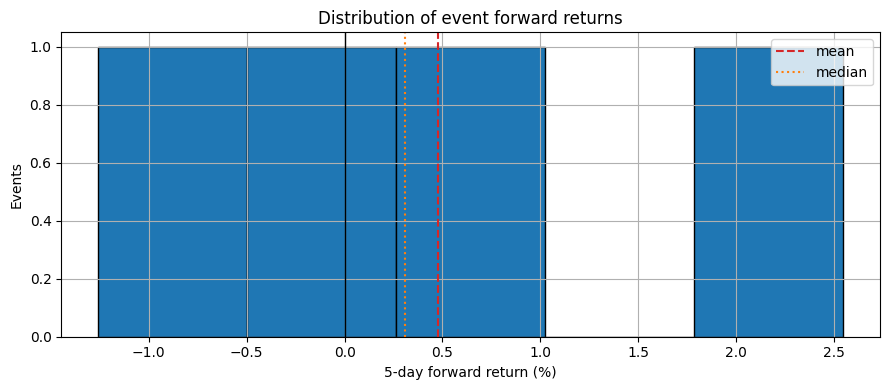

In [12]:
col = f"return_{HOLDING_DAYS}d"
fig, ax = plt.subplots()
ax.hist(events[col].dropna() * 100, bins=min(20, max(5, len(events))), edgecolor="black")
ax.axvline(0, color="black", linewidth=1)
ax.axvline(events[col].mean() * 100, color="tab:red", linestyle="--", label="mean")
ax.axvline(events[col].median() * 100, color="tab:orange", linestyle=":", label="median")
ax.set_xlabel(f"{HOLDING_DAYS}-day forward return (%)")
ax.set_ylabel("Events")
ax.set_title("Distribution of event forward returns")
ax.legend()
plt.tight_layout()
plt.show()


## 11. Statistical evidence

Primary: t-based 95% confidence interval for the mean, plus a one-sided t-test of H0: mean <= 0.

Supporting: percentile bootstrap CI (returns need not be normal).

Statistical significance is not treated as trading significance. A tiny mean with a small p-value can still be useless after costs.


In [13]:
def mean_ci_t(x: pd.Series, alpha: float = ALPHA):
    x = x.dropna().to_numpy()
    n = len(x)
    if n < 2:
        return {"n": n, "mean": np.nan, "ci_low": np.nan, "ci_high": np.nan, "p_one_sided": np.nan}
    mean = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    tcrit = stats.t.ppf(1 - alpha / 2, df=n - 1)
    tstat = mean / se
    p = 1 - stats.t.cdf(tstat, df=n - 1)
    return {
        "n": n,
        "mean": mean,
        "ci_low": mean - tcrit * se,
        "ci_high": mean + tcrit * se,
        "t_stat": tstat,
        "p_one_sided": p,
    }


def bootstrap_mean_ci(x: pd.Series, reps: int = BOOTSTRAP_REPS, alpha: float = ALPHA, seed: int = 42):
    x = x.dropna().to_numpy()
    n = len(x)
    if n < 2:
        return {"boot_ci_low": np.nan, "boot_ci_high": np.nan}
    rng = np.random.default_rng(seed)
    means = rng.choice(x, size=(reps, n), replace=True).mean(axis=1)
    lo, hi = np.quantile(means, [alpha / 2, 1 - alpha / 2])
    return {"boot_mean": means.mean(), "boot_ci_low": lo, "boot_ci_high": hi}


evidence_rows = []
for h in FORWARD_HORIZONS:
    t_res = mean_ci_t(events[f"return_{h}d"])
    b_res = bootstrap_mean_ci(events[f"return_{h}d"])
    evidence_rows.append({"horizon": f"{h}D", **t_res, **b_res})

evidence = pd.DataFrame(evidence_rows).set_index("horizon")
evidence


,n,mean,ci_low,ci_high,t_stat,p_one_sided,boot_mean,boot_ci_low,boot_ci_high
horizon,,,,,,,,,
1D,4,0.001147,-0.013402,0.015695,0.250812,0.409078,0.001151,-0.006905,0.009544
3D,4,0.009776,-0.014562,0.034114,1.278313,0.145535,0.009849,-0.003471,0.023281
5D,4,0.004766,-0.020465,0.029996,0.601133,0.295069,0.004835,-0.007867,0.019074


In [14]:
print("Interpretation keys")
print("- If the 95% CI lies entirely above 0, the sample mean is inconsistently explained by a zero-or-negative true mean under the t model.")
print("- Bootstrap CI is preferred if the histogram is skewed or n is small.")
print("- One-sided p-value tests H0: mean <= 0 vs H1: mean > 0.")
print()
primary = evidence.loc[f"{HOLDING_DAYS}D"]
print(f"Primary {HOLDING_DAYS}D mean: {primary['mean']:.4%}")
print(f"t 95% CI: [{primary['ci_low']:.4%}, {primary['ci_high']:.4%}]")
print(f"bootstrap 95% CI: [{primary['boot_ci_low']:.4%}, {primary['boot_ci_high']:.4%}]")
print(f"one-sided p-value: {primary['p_one_sided']:.4f}")


Interpretation keys
- If the 95% CI lies entirely above 0, the sample mean is inconsistently explained by a zero-or-negative true mean under the t model.
- Bootstrap CI is preferred if the histogram is skewed or n is small.
- One-sided p-value tests H0: mean <= 0 vs H1: mean > 0.

Primary 5D mean: 0.4766%
t 95% CI: [-2.0465%, 2.9996%]
bootstrap 95% CI: [-0.7867%, 1.9074%]
one-sided p-value: 0.2951


## 12. Baseline comparison

A positive event-window return is not enough. NIFTY can have a positive drift on ordinary days too. The baseline is the same holding-period return, entered at the next day's open, on **non-event** days (days that were not kept as events, still requiring enough future bars).


In [15]:
def baseline_table(prices: pd.DataFrame, event_dates: pd.Series, horizons=FORWARD_HORIZONS) -> pd.DataFrame:
    event_set = set(pd.to_datetime(event_dates))
    max_h = max(horizons)
    rows = []
    ret = prices["Close"].pct_change()
    for t in range(1, len(prices) - max_h):
        if prices.loc[t, "Date"] in event_set:
            continue
        if pd.isna(ret.iloc[t]):
            continue
        entry = prices.loc[t + 1, "Open"]
        row = {"date": prices.loc[t, "Date"]}
        for h in horizons:
            row[f"return_{h}d"] = prices.loc[t + h, "Close"] / entry - 1
        rows.append(row)
    return pd.DataFrame(rows)


base = baseline_table(df, events["event_date"] if len(events) else pd.Series(dtype="datetime64[ns]"))

cmp_rows = []
for h in FORWARD_HORIZONS:
    e = summarise_returns(events[f"return_{h}d"] if len(events) else pd.Series(dtype=float))
    b = summarise_returns(base[f"return_{h}d"] if len(base) else pd.Series(dtype=float))
    cmp_rows.append(
        {
            "horizon": f"{h}D",
            "event_n": e.get("n", 0),
            "event_mean": e.get("mean", np.nan),
            "event_median": e.get("median", np.nan),
            "event_win_rate": e.get("win_rate", np.nan),
            "base_n": b.get("n", 0),
            "base_mean": b.get("mean", np.nan),
            "base_median": b.get("median", np.nan),
            "base_win_rate": b.get("win_rate", np.nan),
            "mean_gap": e.get("mean", np.nan) - b.get("mean", np.nan),
        }
    )
comparison = pd.DataFrame(cmp_rows).set_index("horizon")
comparison


,event_n,event_mean,event_median,event_win_rate,base_n,base_mean,base_median,base_win_rate,mean_gap
horizon,,,,,,,,,
1D,4.000000,0.001147,0.000801,0.750000,237.000000,-0.000416,-0.000305,0.472574,0.001563
3D,4.000000,0.009776,0.009518,0.750000,237.000000,-0.000981,-0.000870,0.459916,0.010757
5D,4.000000,0.004766,0.003090,0.500000,237.000000,-0.001276,-0.002899,0.426160,0.006042


In [16]:
# Welch-style comparison of means at the primary horizon (unequal variance).
h = HOLDING_DAYS
if len(events) >= 2 and len(base) >= 2:
    tw = stats.ttest_ind(
        events[f"return_{h}d"].dropna(),
        base[f"return_{h}d"].dropna(),
        equal_var=False,
        alternative="greater",
    )
    print(f"Welch t-test, event mean > baseline mean, {h}D: t={tw.statistic:.3f}, p={tw.pvalue:.4f}")
else:
    print("Not enough observations for a Welch test.")


Welch t-test, event mean > baseline mean, 5D: t=0.755, p=0.2516


## 13. Robustness

The question is not “which cell is largest?” It is whether the **sign and qualitative gap vs baseline** survive nearby, reasonable choices.

Thresholds: −1.5%, −2.0%, −2.5%, −3.0%.  
Holdings: 1, 3, 5, 10 days.  
Cooldown: 0, 3, 5 days (primary threshold and 5-day hold).


In [17]:
thresholds = (-0.015, -0.02, -0.025, -0.03)
holdings = (1, 3, 5, 10)


def mean_at(prices, threshold, cooldown, horizon):
    tbl = build_event_table(prices, threshold, cooldown, horizons=(horizon,))
    if len(tbl) == 0:
        return np.nan, 0
    return tbl[f"return_{horizon}d"].mean(), len(tbl)


grid = []
for thr in thresholds:
    row = {"threshold": thr}
    for h in holdings:
        mu, n = mean_at(df, thr, COOLDOWN_DAYS, h)
        row[f"{h}D_mean"] = mu
        row[f"{h}D_n"] = n
    grid.append(row)
robust_grid = pd.DataFrame(grid)
robust_grid


,threshold,1D_mean,1D_n,3D_mean,3D_n,5D_mean,5D_n,10D_mean,10D_n
0,-0.015000,-0.000042,9,0.002512,9,0.003722,9,0.009728,8
1,-0.020000,0.001147,4,0.009776,4,0.004766,4,0.011007,4
2,-0.025000,0.000188,1,-0.008557,1,-0.012572,1,0.000584,1
3,-0.030000,0.000188,1,-0.008557,1,-0.012572,1,0.000584,1


In [18]:
cooldown_rows = []
for cd in (0, 3, 5):
    tbl = build_event_table(df, EVENT_THRESHOLD, cd, horizons=(HOLDING_DAYS,))
    s = summarise_returns(tbl[f"return_{HOLDING_DAYS}d"] if len(tbl) else pd.Series(dtype=float))
    cooldown_rows.append({"cooldown": cd, "raw_qualifying": tbl.attrs.get("raw_event_count", 0), **s})
cooldown_table = pd.DataFrame(cooldown_rows)
cooldown_table


,cooldown,raw_qualifying,n,mean,median,win_rate,std,min,max
0,0,6,6.000000,0.009721,0.003090,0.500000,0.023041,-0.012572,0.047965
1,3,6,4.000000,0.004766,0.003090,0.500000,0.015856,-0.012572,0.025455
2,5,6,3.000000,-0.000840,-0.000069,0.333333,0.007505,-0.008700,0.006250


## 14. Out-of-sample

Development window: first observation through 31 March 2026.  
Out-of-sample: 1 April 2026 onward.

Parameters are **not** re-tuned on the later window. Same -2% / 5-day / 3-day cooldown rule.

Events are split by **signal date** on the full sample, so a late-March crash is not discarded merely because the 5-day holding window crosses into April.


In [19]:
# Split by signal date on the full event table so a late-March event is not
# dropped just because its 5-day holding window crosses 1 Apr 2026.
dev_mask = df["Date"] < OOS_START
oos_mask = df["Date"] >= OOS_START
print("Development bars:", int(dev_mask.sum()), df.loc[dev_mask, "Date"].min().date(), "→", df.loc[dev_mask, "Date"].max().date())
print("Out-of-sample bars:", int(oos_mask.sum()), df.loc[oos_mask, "Date"].min().date(), "→", df.loc[oos_mask, "Date"].max().date())

if len(events):
    dev_events = events[events["event_date"] < OOS_START].copy()
    oos_events = events[events["event_date"] >= OOS_START].copy()
else:
    dev_events = events
    oos_events = events

oos_cmp = pd.DataFrame(
    {
        "development": summarise_returns(dev_events[f"return_{HOLDING_DAYS}d"] if len(dev_events) else pd.Series(dtype=float)),
        "out_of_sample": summarise_returns(oos_events[f"return_{HOLDING_DAYS}d"] if len(oos_events) else pd.Series(dtype=float)),
    }
).T
oos_cmp


Development bars: 128 2025-09-23 → 2026-03-30
Out-of-sample bars: 119 2026-04-01 → 2026-09-23


,n,mean,median,win_rate,std,min,max
development,3.000000,0.004271,-0.000069,0.333333,0.019382,-0.012572,0.025455
out_of_sample,1.000000,0.006250,0.006250,1.000000,NaN,0.006250,0.006250


In [20]:
print("Development events")
display(dev_events if len(dev_events) else "None")
print("Out-of-sample events")
display(oos_events if len(oos_events) else "None")


Development events


,event_date,event_return,entry_date,entry,return_1d,exit_date_1d,exit_1d,return_3d,exit_date_3d,exit_3d,return_5d,exit_date_5d,exit_5d
0,2026-03-13,-0.020646,2026-03-16,"23,116.100000",0.012662,2026-03-16,"23,408.800000",0.028625,2026-03-18,"23,777.800000",-0.000069,2026-03-20,"23,114.500000"
1,2026-03-19,-0.032621,2026-03-20,"23,110.150000",0.000188,2026-03-20,"23,114.500000",-0.008557,2026-03-24,"22,912.400000",-0.012572,2026-03-27,"22,819.600000"
2,2026-03-27,-0.020889,2026-03-30,"22,549.650000",-0.009679,2026-03-30,"22,331.400000",0.007248,2026-04-02,"22,713.100000",0.025455,2026-04-07,"23,123.650000"


Out-of-sample events


,event_date,event_return,entry_date,entry,return_1d,exit_date_1d,exit_1d,return_3d,exit_date_3d,exit_3d,return_5d,exit_date_5d,exit_5d
3,2026-07-08,-0.021175,2026-07-09,"23,928.950000",0.001415,2026-07-09,"23,962.800000",0.011787,2026-07-13,"24,211.000000",0.006250,2026-07-15,"24,078.500000"


## 15. Challenge the result

Reasons the result can be wrong, even if the tables look tidy:

1. **Look-ahead.** Entry is next open, which is the intended fix. Anyone entering at the event close would be cheating.
2. **Print vs fill.** NIFTY cash index is not directly tradable. Futures/ETF fills will differ from the official open.
3. **Costs and slippage.** A 5 bp + 5 bp round-trip haircut is a lower bound, not a live execution model.
4. **Small sample.** One year of daily data produces few −2% days. Means and p-values are fragile.
5. **Overlapping selloffs.** Cooldown helps; it does not create independence.
6. **Regimes.** If almost all events sit inside one March–April drawdown, this is a single-episode study, not a general NIFTY law.
7. **Data quality.** One Close=6 row would have manufactured a −99% “event” if it had been kept.
8. **Data snooping.** The robustness grid is for stability, not for picking a winner after the fact.

**What would reject the hypothesis under this methodology:** event means not consistently positive; event vs baseline gap not material; or the frozen rule failing out of sample.


In [21]:
print("Event dates (full sample, de-clustered)")
if len(events):
    display(events[["event_date", "event_return", "entry", f"return_{HOLDING_DAYS}d"]])
    span = (events["event_date"].max() - events["event_date"].min()).days
    print(f"Event date span: {span} calendar days")
    print("Share of events in Mar-Apr 2026:",
          ((events["event_date"] >= "2026-03-01") & (events["event_date"] <= "2026-04-30")).mean())
else:
    print("No events under the primary rule.")


Event dates (full sample, de-clustered)


,event_date,event_return,entry,return_5d
0,2026-03-13,-0.020646,"23,116.100000",-0.000069
1,2026-03-19,-0.032621,"23,110.150000",-0.012572
2,2026-03-27,-0.020889,"22,549.650000",0.025455
3,2026-07-08,-0.021175,"23,928.950000",0.006250


Event date span: 117 calendar days
Share of events in Mar-Apr 2026: 0.75


## 16. Event-driven backtest

Rule (after all research choices are fixed):

1. Significant fall (≤ −2% close-to-close), after cooldown filter.  
2. Buy at the next session open.  
3. Hold `HOLDING_DAYS` trading days.  
4. Sell at that day's close.  
5. Net return = gross − transaction cost − slippage.

This is a **sequential** trade list. If a new signal appears while a trade is open, it is ignored (flat-or-in, no overlapping positions). That is stricter than the event table, which can still have overlapping evaluation windows.


In [22]:
def backtest(prices: pd.DataFrame, threshold: float, cooldown: int, holding: int,
             cost: float = TRANSACTION_COST, slip: float = SLIPPAGE) -> pd.DataFrame:
    ret = prices["Close"].pct_change()
    raw_pos = np.flatnonzero((ret <= threshold).to_numpy())
    raw_pos = raw_pos[(raw_pos + holding) < len(prices)]
    kept = decluster_events(raw_pos, cooldown)

    trades = []
    occupied_until = -1
    equity = 1.0
    peak = 1.0
    for t in kept:
        entry_i = t + 1
        exit_i = t + holding
        if entry_i <= occupied_until:
            continue  # already in a position
        entry_px = prices.loc[entry_i, "Open"]
        exit_px = prices.loc[exit_i, "Close"]
        gross = exit_px / entry_px - 1
        net = gross - cost - slip
        equity *= 1 + net
        peak = max(peak, equity)
        dd = equity / peak - 1
        trades.append(
            {
                "event_date": prices.loc[t, "Date"],
                "entry_date": prices.loc[entry_i, "Date"],
                "exit_date": prices.loc[exit_i, "Date"],
                "entry": entry_px,
                "exit": exit_px,
                "gross_return": gross,
                "cost": cost,
                "slippage": slip,
                "net_return": net,
                "equity": equity,
                "drawdown": dd,
            }
        )
        occupied_until = exit_i
    return pd.DataFrame(trades)


trades = backtest(df, EVENT_THRESHOLD, COOLDOWN_DAYS, HOLDING_DAYS)
trades


,event_date,entry_date,exit_date,entry,exit,gross_return,cost,slippage,net_return,equity,drawdown
0,2026-03-13,2026-03-16,2026-03-20,"23,116.100000","23,114.500000",-0.000069,0.000500,0.000500,-0.001069,0.998931,-0.001069
1,2026-03-27,2026-03-30,2026-04-07,"22,549.650000","23,123.650000",0.025455,0.000500,0.000500,0.024455,1.023360,0.000000
2,2026-07-08,2026-07-09,2026-07-15,"23,928.950000","24,078.500000",0.006250,0.000500,0.000500,0.005250,1.028732,0.000000


Number of trades: 3
Win rate (net): 0.6666666666666666
Mean net return: 0.009545158861327377
Median net return: 0.005249751869597197
Cumulative growth factor: 1.0287319609580627
Cumulative return: 0.02873196095806274
Max drawdown (trade-equity mark): -0.001069215827929404


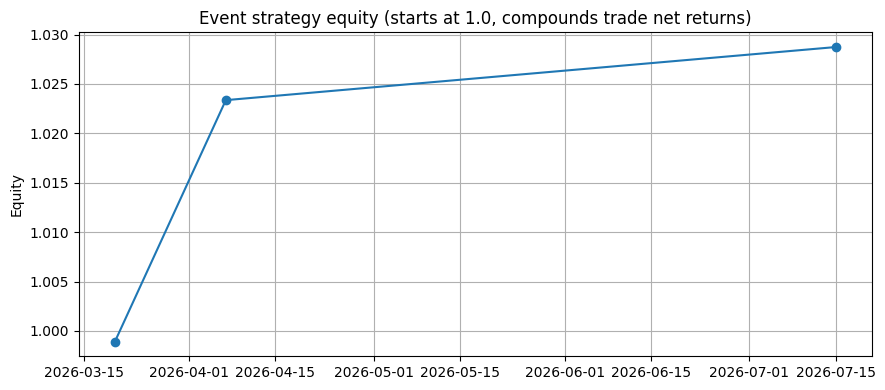

Buy-and-hold close-to-close over the file: -0.06844395001887205


In [23]:
if len(trades) == 0:
    print("No trades.")
else:
    equity_end = trades["equity"].iloc[-1]
    mdd = trades["drawdown"].min()
    print("Number of trades:", len(trades))
    print("Win rate (net):", (trades["net_return"] > 0).mean())
    print("Mean net return:", trades["net_return"].mean())
    print("Median net return:", trades["net_return"].median())
    print("Cumulative growth factor:", equity_end)
    print("Cumulative return:", equity_end - 1)
    print("Max drawdown (trade-equity mark):", mdd)

    fig, ax = plt.subplots()
    ax.plot(trades["exit_date"], trades["equity"], marker="o")
    ax.set_title("Event strategy equity (starts at 1.0, compounds trade net returns)")
    ax.set_ylabel("Equity")
    plt.tight_layout()
    plt.show()

    # Buy-and-hold over the same full sample, for context only (different risk, always invested).
    bh = df["Close"].iloc[-1] / df["Close"].iloc[0] - 1
    print("Buy-and-hold close-to-close over the file:", bh)


## 17. Conclusion

Run the cells above and read the printed numbers against the pre-committed failure conditions:

- Are 1D / 3D / 5D event means positive?
- Is the event mean materially above the ordinary-day baseline?
- Does the frozen −2% / 5-day / 3-day-cooldown rule still work after 1 Apr 2026?
- After 10 bps of round-trip friction, is anything economically left?

With only about one year of NIFTY history in this folder, a non-result is still a valid research outcome. The notebook is designed to report that honestly rather than retune the threshold until the backtest looks good.

The two-page summary lives in `RESEARCH_NOTE.md`.

On this specific one-year file the pre-committed tests do **not** support the hypothesis: n = 4 de-clustered events, 5-day mean +0.48% with a 95% CI that includes zero (one-sided p ≈ 0.30), 3 of 4 events sit in the March 2026 selloff, and the development-window 5-day mean is not a clean positive result. The backtest's small cumulative gain is three trades, not a validated edge.


In [24]:
print("=== FROZEN PRIMARY SPEC ===")
print("threshold", EVENT_THRESHOLD, "| holding", HOLDING_DAYS, "| cooldown", COOLDOWN_DAYS)
print("file", DATA_PATH.name)
print("obs", len(df), df["Date"].min().date(), "→", df["Date"].max().date())
print("events", len(events), "trades", len(trades) if isinstance(trades, pd.DataFrame) else 0)
if len(events):
    print(event_stats)
    print(comparison)
    print(evidence)
    print(oos_cmp)


=== FROZEN PRIMARY SPEC ===
threshold -0.02 | holding 5 | cooldown 3
file NIFTY 50-23-09-2025-to-23-09-2026.csv
obs 247 2025-09-23 → 2026-09-23
events 4 trades 3
          n     mean   median  win_rate      std       min      max
1D 4.000000 0.001147 0.000801  0.750000 0.009143 -0.009679 0.012662
3D 4.000000 0.009776 0.009518  0.750000 0.015295 -0.008557 0.028625
5D 4.000000 0.004766 0.003090  0.500000 0.015856 -0.012572 0.025455
         event_n  event_mean  event_median  event_win_rate     base_n  \
horizon                                                                 
1D      4.000000    0.001147      0.000801        0.750000 237.000000   
3D      4.000000    0.009776      0.009518        0.750000 237.000000   
5D      4.000000    0.004766      0.003090        0.500000 237.000000   

         base_mean  base_median  base_win_rate  mean_gap  
horizon                                                   
1D       -0.000416    -0.000305       0.472574  0.001563  
3D       -0.000981    -